In [1]:
import matplotlib.pyplot as plt
import pathlib, os, random
import numpy as np
import pandas as pd
import tensorflow as tf
import keras


from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Activation, BatchNormalization, Dropout , GlobalAveragePooling2D
from keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
from keras.callbacks import Callback, EarlyStopping,ModelCheckpoint

In [2]:
train_path="C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\7030\\train\\"
no_birds_classes = os.listdir(train_path)
len(no_birds_classes)

41

In [3]:
data_dir = pathlib.Path("C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\7030\\train\\")
BirdClasses = np.array(([item.name for item in data_dir.glob("*")]))
print(BirdClasses)

['babblers bird' 'barbets bird' 'bulbuls bird' 'coots bird' 'cranes bird'
 'cuckoos bird' 'Doves bird' 'Drongos bird' 'Ducks bird' 'Eagles bird'
 'Egrets bird' 'Falcons bird' 'Finches bird' 'Flycatchers bird'
 'Herons bird' 'Hornbills bird' 'Jacanas bird' 'kingfishers bird'
 'munias bird' 'nightjars bird' 'orioles bird' 'owls bird'
 'parakeets bird' 'peafowl bird' 'pesants bird' 'pigeons bird'
 'plovers bird' 'prinias bird' 'robins bird' 'sandpipers bird'
 'shrikes bird' 'storks bird' 'sunbirds bird' 'swallows bird'
 'swamphens bird' 'swifts bird' 'terns bird' 'tits bird' 'wagtails bird'
 'warblers bird' 'woodpeckers bird']


# visualising the images

In [4]:
def view_random_image(target_dir, target_class):
  
  # setting up the image directory
  target_folder = target_dir +'\\' + target_class

  #get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  #read image and plotting it
  img = plt.imread(target_folder + "\\" + random_image[0] )
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off")

  #print(f"Image shape: {img.shape}")
  
  return img

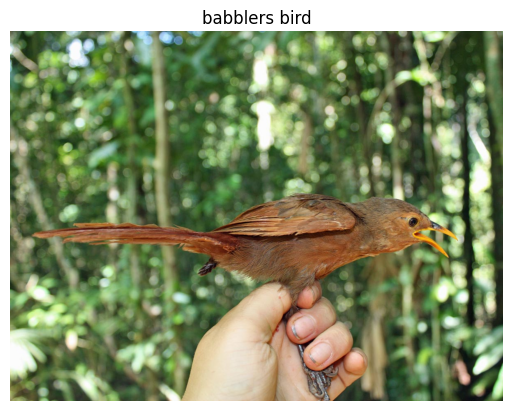

In [5]:
img = view_random_image(train_path,'babblers bird' )

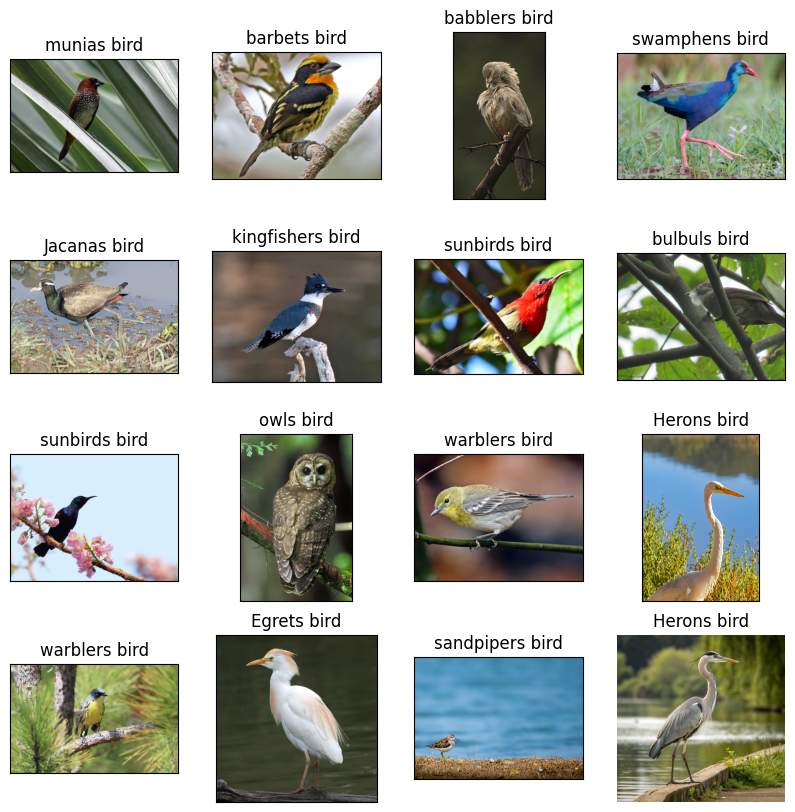

In [6]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

random_index = np.random.randint(0 , len(BirdClasses)-1 , 16)

for i, ax in enumerate(axes.flat):
    ax.imshow(view_random_image(train_path,BirdClasses[random_index[i]]))
    ax.set_title(BirdClasses[random_index[i]])

# data preprocessing 

In [7]:
train_dir = "C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\7030\\train\\"
test_dir ="C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\7030\\test\\"
val_dir ="C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\7030\\val\\"

In [8]:
from keras.applications.mobilenet_v2 import MobileNetV2

In [9]:
train_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory( train_dir , target_size=(224,224) , batch_size=32 , class_mode = "categorical" ,shuffle=True )

val_data = val_gen.flow_from_directory( val_dir , target_size=(224,224) , batch_size=32 , class_mode = "categorical" , shuffle=True )

test_data = test_gen.flow_from_directory( test_dir , target_size=(224,224) , batch_size=32 , class_mode = "categorical" ,shuffle=False )

Found 4303 images belonging to 41 classes.
Found 902 images belonging to 41 classes.
Found 942 images belonging to 41 classes.


# Preparing MobileNet Pretrained Model

In [10]:
mobilenet = tf.keras.applications.mobilenet_v2.MobileNetV2( include_top=False , weights="imagenet" , input_shape=(224,224,3))

mobilenet.summary()

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                              

 block_3_expand_relu (ReLU)     (None, 56, 56, 144)  0           ['block_3_expand_BN[0][0]']      
                                                                                                  
 block_3_pad (ZeroPadding2D)    (None, 57, 57, 144)  0           ['block_3_expand_relu[0][0]']    
                                                                                                  
 block_3_depthwise (DepthwiseCo  (None, 28, 28, 144)  1296       ['block_3_pad[0][0]']            
 nv2D)                                                                                            
                                                                                                  
 block_3_depthwise_BN (BatchNor  (None, 28, 28, 144)  576        ['block_3_depthwise[0][0]']      
 malization)                                                                                      
                                                                                                  
 block_3_d

 lization)                                                                                        
                                                                                                  
 block_7_expand (Conv2D)        (None, 14, 14, 384)  24576       ['block_6_project_BN[0][0]']     
                                                                                                  
 block_7_expand_BN (BatchNormal  (None, 14, 14, 384)  1536       ['block_7_expand[0][0]']         
 ization)                                                                                         
                                                                                                  
 block_7_expand_relu (ReLU)     (None, 14, 14, 384)  0           ['block_7_expand_BN[0][0]']      
                                                                                                  
 block_7_depthwise (DepthwiseCo  (None, 14, 14, 384)  3456       ['block_7_expand_relu[0][0]']    
 nv2D)    

                                                                                                  
 block_10_depthwise_relu (ReLU)  (None, 14, 14, 384)  0          ['block_10_depthwise_BN[0][0]']  
                                                                                                  
 block_10_project (Conv2D)      (None, 14, 14, 96)   36864       ['block_10_depthwise_relu[0][0]']
                                                                                                  
 block_10_project_BN (BatchNorm  (None, 14, 14, 96)  384         ['block_10_project[0][0]']       
 alization)                                                                                       
                                                                                                  
 block_11_expand (Conv2D)       (None, 14, 14, 576)  55296       ['block_10_project_BN[0][0]']    
                                                                                                  
 block_11_

 block_14_depthwise (DepthwiseC  (None, 7, 7, 960)   8640        ['block_14_expand_relu[0][0]']   
 onv2D)                                                                                           
                                                                                                  
 block_14_depthwise_BN (BatchNo  (None, 7, 7, 960)   3840        ['block_14_depthwise[0][0]']     
 rmalization)                                                                                     
                                                                                                  
 block_14_depthwise_relu (ReLU)  (None, 7, 7, 960)   0           ['block_14_depthwise_BN[0][0]']  
                                                                                                  
 block_14_project (Conv2D)      (None, 7, 7, 160)    153600      ['block_14_depthwise_relu[0][0]']
                                                                                                  
 block_14_

# Fine-Tuning MobileNet Model

In [11]:
# Freezing all layers except the last 20 layers

mobilenet.trainable=True
"""
for layer in mobilenet.layers[:-20]:
  layer.trainable=False
"""

'\nfor layer in mobilenet.layers[:-20]:\n  layer.trainable=False\n'

In [12]:
Model = Sequential([
    mobilenet,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256,activation='relu'),
    BatchNormalization(),
    Dense(41,activation='softmax')
])

Model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 batch_normalization_1 (Batc  (None, 256)              1024      
 hNormalization)                                        

In [13]:
#Model.compile( optimizer="adam", loss="categorical_crossentropy" , metrics=["accuracy"] )
Model.compile(optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, decay=1e-6, momentum=0.9, nesterov=True),
               loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

In [14]:
# Create Callback Checkpoint

#checkpoint_path = "BirdsSpecies_Model_Checkpoint"
#checkpoint_callback = ModelCheckpoint(checkpoint_path,monitor="val_accuracy",save_best_only=True)

callbacks = [EarlyStopping(monitor='val_accuracy' , patience=5 , restore_best_weights=True)]

In [15]:
history = Model.fit(train_data,epochs=50,batch_size=32 ,steps_per_epoch = len(train_data)
,callbacks=callbacks , validation_data=val_data,validation_steps = len(val_data))

Epoch 1/50
135/135 [==============================] - 146s 931ms/step - loss: 2.0510 - accuracy: 0.4790 - val_loss: 2.3837 - val_accuracy: 0.3659
Epoch 2/50
135/135 [==============================] - 127s 944ms/step - loss: 0.5760 - accuracy: 0.8647 - val_loss: 2.0900 - val_accuracy: 0.4579
Epoch 3/50
135/135 [==============================] - 127s 942ms/step - loss: 0.2362 - accuracy: 0.9600 - val_loss: 1.8282 - val_accuracy: 0.5288
Epoch 4/50
135/135 [==============================] - 127s 938ms/step - loss: 0.1182 - accuracy: 0.9881 - val_loss: 1.4938 - val_accuracy: 0.6153
Epoch 5/50
135/135 [==============================] - 127s 935ms/step - loss: 0.0709 - accuracy: 0.9970 - val_loss: 1.1988 - val_accuracy: 0.7095
Epoch 6/50
135/135 [==============================] - 127s 940ms/step - loss: 0.0460 - accuracy: 0.9988 - val_loss: 1.0948 - val_accuracy: 0.7140
Epoch 7/50
135/135 [==============================] - 128s 946ms/step - loss: 0.0370 - accuracy: 0.9995 - val_loss: 0.9602 -

In [16]:

Model.save("70_30_mobilenetv2.h5")

In [17]:
test_gen = ImageDataGenerator(rescale=1./255)
test_data = test_gen.flow_from_directory( test_dir , target_size=(224,224) , batch_size=1 , class_mode = "categorical" ,shuffle=False )
filenames = test_data.filenames
nb_samples = len(filenames)

prediction = Model.predict(test_data ,steps = nb_samples)

Found 942 images belonging to 41 classes.
942/942 [==============================] - 29s 29ms/step


In [18]:
from sklearn.metrics import classification_report, confusion_matrix


y_pred = np.argmax(prediction, axis=1)
#y_pred=np.asarray(prediction)
print('Confusion Matrix')
print(confusion_matrix(test_data.classes, y_pred))
print('Classification Report')
target_names =BirdClasses  
print(classification_report(test_data.classes, y_pred, target_names=BirdClasses))


Confusion Matrix
[[17  0  0 ...  0  0  0]
 [ 0 21  0 ...  0  0  0]
 [ 0  0 20 ...  0  0  0]
 ...
 [ 0  1  0 ... 20  1  0]
 [ 0  0  0 ...  1 16  0]
 [ 2  0  0 ...  0  0 19]]
Classification Report
                  precision    recall  f1-score   support

   babblers bird       0.65      0.74      0.69        23
    barbets bird       0.91      0.91      0.91        23
    bulbuls bird       0.95      0.87      0.91        23
      coots bird       0.76      0.70      0.73        23
     cranes bird       0.80      0.87      0.83        23
    cuckoos bird       0.78      0.78      0.78        23
      Doves bird       0.75      0.65      0.70        23
    Drongos bird       0.62      0.70      0.65        23
      Ducks bird       0.70      0.70      0.70        23
     Eagles bird       1.00      0.87      0.93        23
     Egrets bird       0.90      0.83      0.86        23
    Falcons bird       0.79      0.65      0.71        23
    Finches bird       0.68      0.83      0.75   